In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import clone
import pandas as pd
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.base import clone
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import time

from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler


from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif, SelectPercentile, SelectFpr, SelectFwe, SelectFdr, GenericUnivariateSelect, VarianceThreshold

from imblearn.over_sampling import (
    SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE, KMeansSMOTE
)
from imblearn.combine import SMOTETomek
import smote_variants as sv  # For advanced SMOTE methods

import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"  # Replace with number of logical cores

import smote_variants as sv

In [3]:
df= pd.read_csv(r"C:\Users\mumer\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.drop('customerID', axis=1, inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
df.dropna(subset=['TotalCharges'], inplace=True)

In [10]:
df.duplicated().sum()

22

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


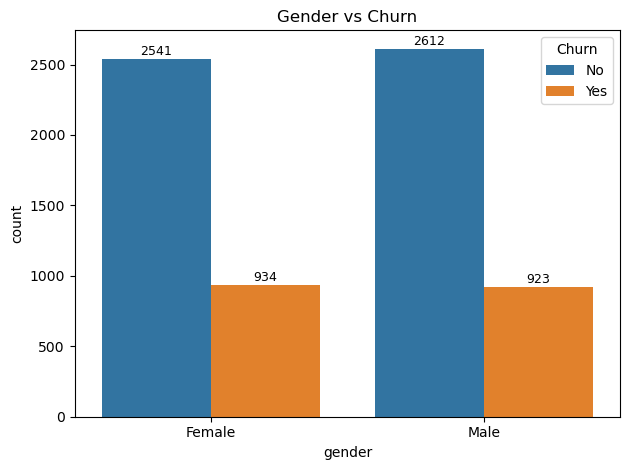

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the grouped bar chart
ax = sns.countplot(data=df, x='gender', hue='Churn')
plt.title('Gender vs Churn')

# Add value labels only on non-zero bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Avoid annotating bars with height 0
        x = p.get_x() + p.get_width() / 2
        ax.text(x, height + 5, f'{int(height)}', ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.show()


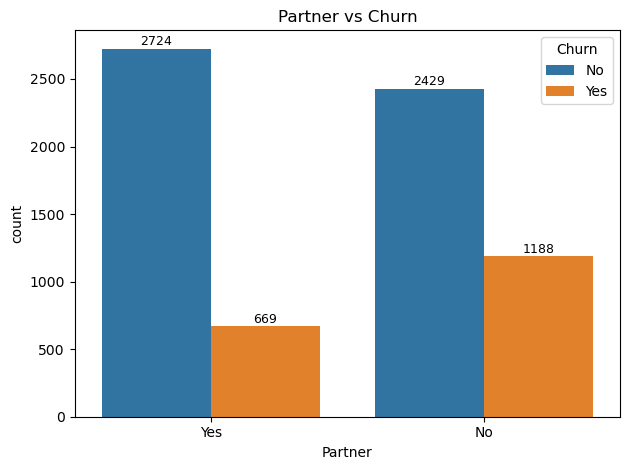

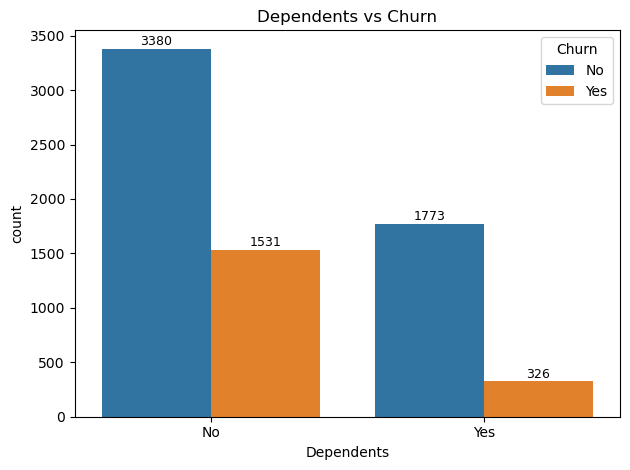

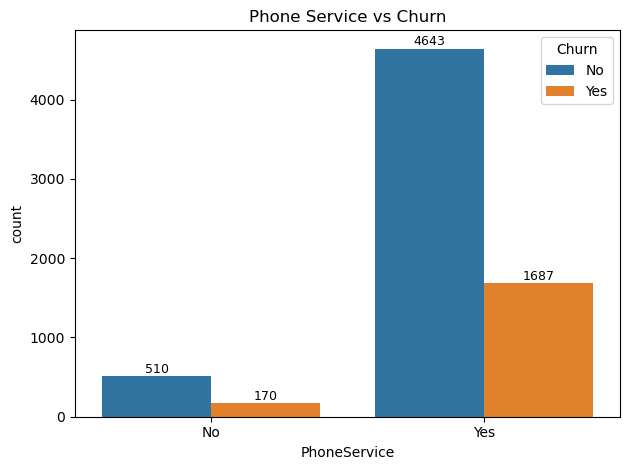

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Function to plot and annotate
def annotated_countplot(df, x_col, hue_col, title):
    ax = sns.countplot(data=df, x=x_col, hue=hue_col)
    plt.title(title)
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            x = p.get_x() + p.get_width() / 2
            ax.text(x, height + 5, f'{int(height)}', ha='center', va='bottom', fontsize=9, color='black')
    
    plt.tight_layout()
    plt.show()

# Apply to each case
annotated_countplot(df, 'Partner', 'Churn', 'Partner vs Churn')
annotated_countplot(df, 'Dependents', 'Churn', 'Dependents vs Churn')
annotated_countplot(df, 'PhoneService', 'Churn', 'Phone Service vs Churn')


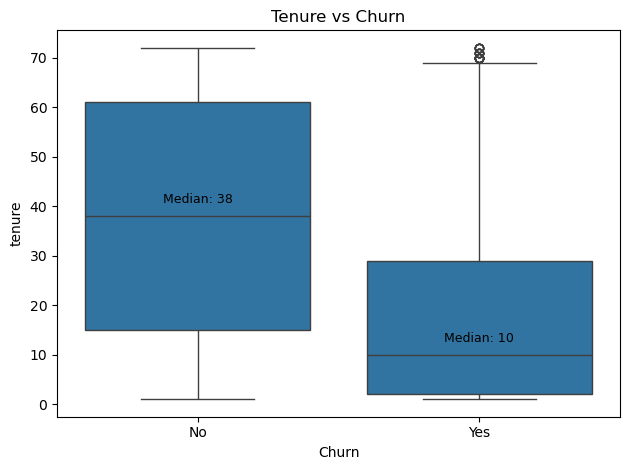

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create the boxplot
ax = sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure vs Churn')

# Annotate median values on the plot
medians = df.groupby('Churn')['tenure'].median()
positions = range(len(medians))

for pos, label in zip(positions, medians):
    ax.text(pos, label + 2, f'Median: {label:.0f}', ha='center', va='bottom',
            fontsize=9, color='black')

plt.tight_layout()
plt.show()


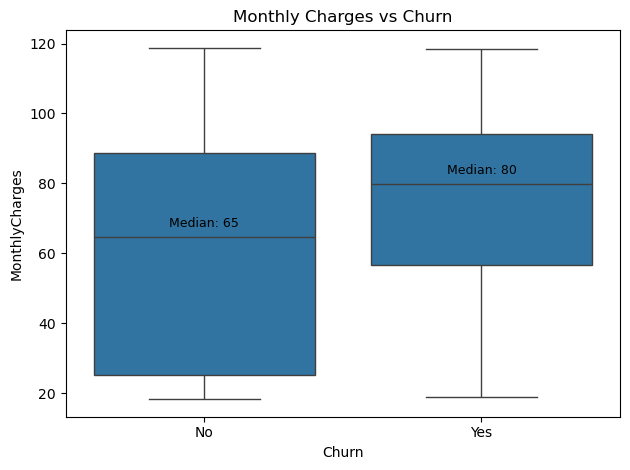

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the boxplot
ax = sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')

# Compute and annotate median values
medians = df.groupby('Churn')['MonthlyCharges'].median()
positions = range(len(medians))

for pos, value in zip(positions, medians):
    ax.text(pos, value + 2, f'Median: {value:.0f}', ha='center', va='bottom',
            fontsize=9, color='black')

plt.tight_layout()
plt.show()


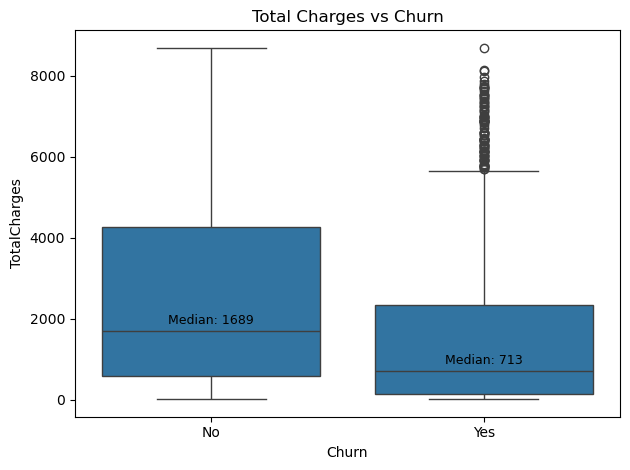

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the boxplot
ax = sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title('Total Charges vs Churn')

# Compute and annotate median values
medians = df.groupby('Churn')['TotalCharges'].median()
positions = range(len(medians))

for pos, value in zip(positions, medians):
    ax.text(pos, value + 100, f'Median: {value:.0f}', ha='center', va='bottom',
            fontsize=9, color='black')

plt.tight_layout()
plt.show()



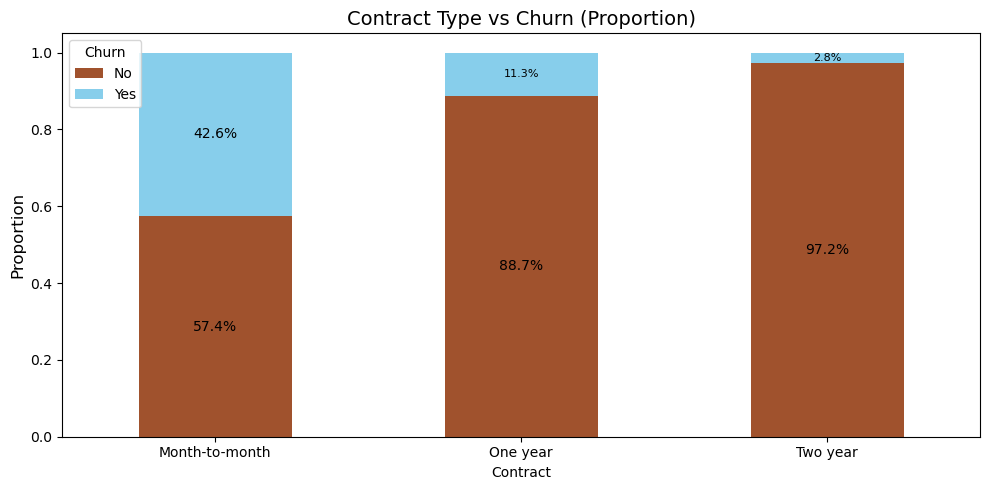

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Compute normalized churn proportions
ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index')

# Set up a well-sized figure
fig, ax = plt.subplots(figsize=(10, 5))  # Wider layout for clean spacing

# Define custom colors
colors = ['#A0522D', '#87CEEB']  # No churn, Yes churn
ct.plot(kind='bar', stacked=True, color=colors, ax=ax)

# Title & axis styling
plt.title('Contract Type vs Churn (Proportion)', fontsize=14)
plt.ylabel('Proportion', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

# Add percentage labels with smart font sizing
for bars in ax.containers:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            x = bar.get_x() + bar.get_width() / 2
            y = bar.get_y() + height / 2
            fontsize = 8 if height < 0.12 else 10  # Slight font tweak for thin bars
            ax.text(x, y, f'{height * 100:.1f}%', ha='center', va='center',
                    fontsize=fontsize, color='black')

plt.tight_layout()
plt.show()


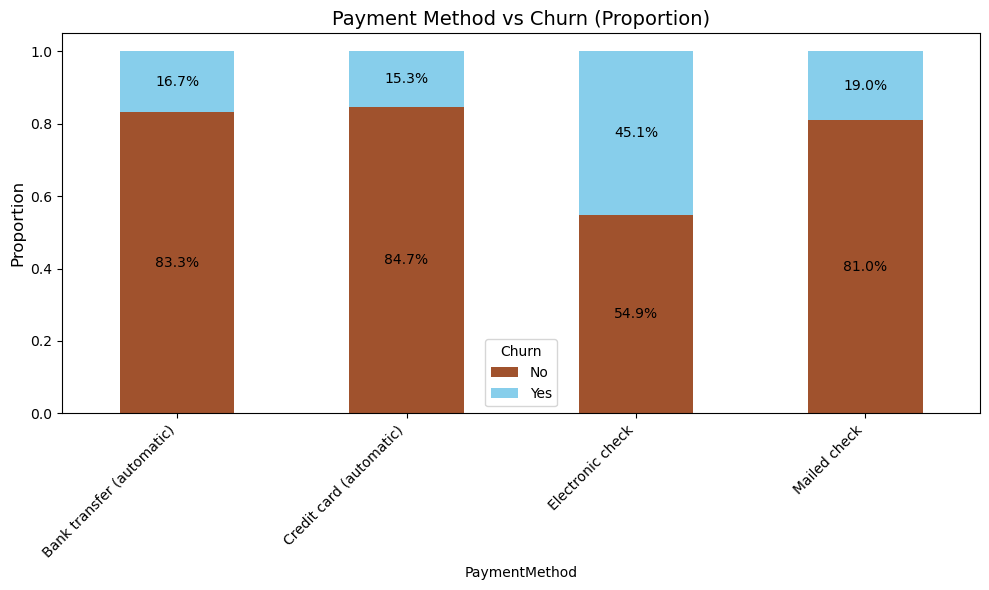

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Normalize data
ct = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')

# Set up figure with larger size
fig, ax = plt.subplots(figsize=(10, 6))  # Wider and taller for better spacing

# Use custom colors
colors = ['#A0522D', '#87CEEB']  # Adjust as needed for contrast or branding
ct.plot(kind='bar', stacked=True, color=colors, ax=ax)

# Styling
plt.title('Payment Method vs Churn (Proportion)', fontsize=14)
plt.ylabel('Proportion', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Annotate cleanly
for bars in ax.containers:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            x = bar.get_x() + bar.get_width() / 2
            y = bar.get_y() + height / 2
            fontsize = 8 if height < 0.12 else 10
            ax.text(x, y, f'{height * 100:.1f}%', ha='center', va='center',
                    fontsize=fontsize, color='black')

plt.tight_layout()
plt.show()


In [19]:
for col in df.columns:
    print('Unique values of ' + col)
    print(df[col].unique())
    print("======================")

Unique values of gender
['Female' 'Male']
Unique values of SeniorCitizen
[0 1]
Unique values of Partner
['Yes' 'No']
Unique values of Dependents
['No' 'Yes']
Unique values of tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
Unique values of PhoneService
['No' 'Yes']
Unique values of MultipleLines
['No phone service' 'No' 'Yes']
Unique values of InternetService
['DSL' 'Fiber optic' 'No']
Unique values of OnlineSecurity
['No' 'Yes' 'No internet service']
Unique values of OnlineBackup
['Yes' 'No' 'No internet service']
Unique values of DeviceProtection
['No' 'Yes' 'No internet service']
Unique values of TechSupport
['No' 'Yes' 'No internet service']
Unique values of StreamingTV
['No' 'Yes' 'No internet service']
Unique values of StreamingMovies
['No' 'Yes' 'No internet service']
Unique values of Contract
['Month-t

In [20]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

In [21]:
onehot_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True, dtype=int)

In [22]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,72,1,1,103.20,7362.90,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,11,0,1,29.60,346.45,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,4,1,1,74.40,306.60,1,...,0,0,0,0,0,0,0,0,0,1


In [23]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [24]:
X.shape, y.value_counts()

((7010, 30),
 Churn
 0    5153
 1    1857
 Name: count, dtype: int64)

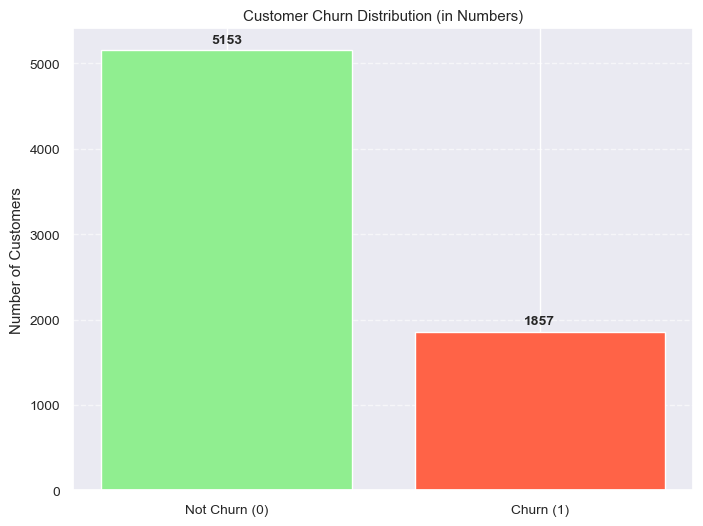

In [55]:
import matplotlib.pyplot as plt

# Get counts
churn_counts = df['Churn'].value_counts().sort_index()
labels = ['Not Churn (0)', 'Churn (1)']
colors = ['lightgreen', 'tomato']

# Plot bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, churn_counts, color=colors)

# Title and axis labels
plt.title('Customer Churn Distribution (in Numbers)')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bar values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(churn_counts)*0.01,
             str(height), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()


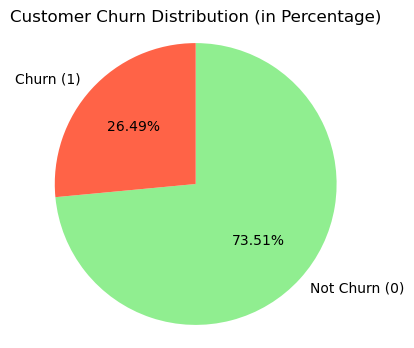

In [25]:
import matplotlib.pyplot as plt

# After mapping: Churn column values are 1 = Yes (Churn), 0 = No (Not Churn)
churn_counts = df['Churn'].value_counts().sort_index()
labels = ['Not Churn (0)', 'Churn (1)']
colors = ['lightgreen', 'tomato']  # Green for retention, red for churn

# Plot
plt.figure(figsize=(4, 4))
plt.pie(churn_counts, labels=labels, colors=colors, autopct='%.2f%%', startangle=90, counterclock=False)
plt.title('Customer Churn Distribution (in Percentage)')
plt.axis('equal')  # Ensures pie is circular

plt.show()


In [26]:
feature_selectors = {
    "SelectKBest (F-value)": SelectKBest(score_func=f_classif, k=10),
    "SelectKBest (Chi²)": SelectKBest(score_func=chi2, k=10),
    "SelectKBest (Mutual Info)": SelectKBest(score_func=mutual_info_classif, k=10),
    "SelectPercentile (F-value)": SelectPercentile(f_classif, percentile=50),
    "SelectFpr (p-value)": SelectFpr(f_classif, alpha=0.05),
    "SelectFwe (Family-wise Error)": SelectFwe(f_classif, alpha=0.05),
    "SelectFdr (False Discovery Rate)": SelectFdr(f_classif, alpha=0.05),
    "Variance Threshold": VarianceThreshold(threshold=0.01),
    "GenericUnivariateSelect (F)": GenericUnivariateSelect(score_func=f_classif, mode="percentile", param=50),
    "GenericUnivariateSelect (Mutual Info)": GenericUnivariateSelect(score_func=mutual_info_classif, mode="k_best", param=10),
}

In [27]:
oversamplers = {
    "ADASYN": ADASYN(),
    "BorderlineSMOTE": BorderlineSMOTE(),
    "KMeansSMOTE": KMeansSMOTE(cluster_balance_threshold=0.01, kmeans_estimator=3),
    "SMOTETomek": SMOTETomek(),
    
    # From smote-variants
    "DistanceSMOTE": sv.distance_SMOTE(),
    "V_SYNTH": sv.V_SYNTH(),
    "ROSE": sv.ROSE(),
    "PDFOS": sv.PDFOS(),
    "MDO": sv.MDO(),
    "polynom_fit_SMOTE_star": sv.polynom_fit_SMOTE_star(),
}

In [28]:
from catboost import CatBoostClassifier

classifiers = {
    'LogisticRegression': LogisticRegression(max_iter=1000, solver='liblinear'),
    'DecisionTree': DecisionTreeClassifier(),
    'RandomForest': RandomForestClassifier(),
    'GradientBoosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(algorithm='SAMME'),
    'CatBoost': CatBoostClassifier(verbose=0), 
    'NaiveBayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(eval_metric='logloss'),
    'LDA': LinearDiscriminantAnalysis()
}


In [29]:
import warnings
import logging

# Ignore all warnings
warnings.filterwarnings("ignore")

# Disable smote-variants logging
logging.getLogger('smote_variants').setLevel(logging.ERROR)

In [30]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
confusion_data = []  # To store predictions for confusion matrices

total_combinations = len(feature_selectors) * len(oversamplers) * len(classifiers)
combo_count = 1

print(f"\n🔁 Starting full pipeline with {total_combinations} total combinations...\n")

for fs_name, selector in tqdm(feature_selectors.items(), desc="Feature Selection"):
    for smote_name, sampler in oversamplers.items():
        for clf_name, clf in classifiers.items():
            print(f"\n➡️ [{combo_count}/{total_combinations}] Processing: FS={fs_name} | SMOTE={smote_name} | Classifier={clf_name}")
            combo_count += 1
            start_time = time.time()
            fold_scores = []

            try:
                for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
                    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
                    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

                    # 🔁 Scaler depends on selector
                    scaler = MinMaxScaler() if "Chi²" in fs_name else StandardScaler()

                    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
                    X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X.columns)

                    # 🔁 Feature selection
                    X_train_fs = selector.fit_transform(X_train_scaled, y_train)
                    X_val_fs = selector.transform(X_val_scaled)

                    # 🔁 Oversampling
                    if smote_name in ['DistanceSMOTE',"V_SYNTH", "PDFOS", "ROSE", "MDO","polynom_fit_SMOTE_star"]:
                        X_res, y_res = sampler.sample(X_train_fs, y_train.values)
                    else:
                        X_res, y_res = sampler.fit_resample(X_train_fs, y_train)

                    if len(np.unique(y_res)) < 2:
                        print("⚠️ Skipping due to single class after resampling.")
                        continue

                    # 🔁 Train model
                    model = clone(clf)
                    model.fit(X_res, y_res)
                    y_pred = model.predict(X_val_fs)

                    # 🔁 Save last fold prediction for confusion matrix
                    if fold == 5:
                        confusion_data.append({
                            "Selector": fs_name,
                            "Oversampler": smote_name,
                            "Classifier": clf_name,
                            "y_true": y_val,
                            "y_pred": y_pred
                        })

                    # 🔁 Metrics
                    fold_scores.append({
                        "Accuracy": accuracy_score(y_val, y_pred),
                        "Precision": precision_score(y_val, y_pred, zero_division=0),
                        "Recall": recall_score(y_val, y_pred),
                        "F1": f1_score(y_val, y_pred)
                    })

                    print(f"   ✅ Fold {fold}: Acc={fold_scores[-1]['Accuracy']:.4f}, F1={fold_scores[-1]['F1']:.4f}")

                avg = pd.DataFrame(fold_scores).mean()
                print(f"✅ DONE: Acc={avg['Accuracy']:.4f}, F1={avg['F1']:.4f} | Time: {(time.time() - start_time):.2f}s")

                results.append({
                    "Selector": fs_name,
                    "Oversampler": smote_name,
                    "Classifier": clf_name,
                    "Accuracy": round(avg["Accuracy"], 4),
                    "Precision": round(avg["Precision"], 4),
                    "Recall": round(avg["Recall"], 4),
                    "F1": round(avg["F1"], 4)
                })

            except Exception as e:
                print(f"❌ Failed: FS={fs_name} | SMOTE={smote_name} | Classifier={clf_name} | Error: {e}")
                continue


🔁 Starting full pipeline with 1000 total combinations...



Feature Selection:   0%|                                                                        | 0/10 [00:00<?, ?it/s]


➡️ [1/1000] Processing: FS=SelectKBest (F-value) | SMOTE=ADASYN | Classifier=LogisticRegression
   ✅ Fold 1: Acc=0.7261, F1=0.6145
   ✅ Fold 2: Acc=0.7126, F1=0.6045
   ✅ Fold 3: Acc=0.7197, F1=0.6042
   ✅ Fold 4: Acc=0.7054, F1=0.5899
   ✅ Fold 5: Acc=0.7183, F1=0.6077
✅ DONE: Acc=0.7164, F1=0.6042 | Time: 0.37s

➡️ [2/1000] Processing: FS=SelectKBest (F-value) | SMOTE=ADASYN | Classifier=DecisionTree
   ✅ Fold 1: Acc=0.7411, F1=0.5998
   ✅ Fold 2: Acc=0.7489, F1=0.6115
   ✅ Fold 3: Acc=0.7511, F1=0.6092
   ✅ Fold 4: Acc=0.7190, F1=0.5670
   ✅ Fold 5: Acc=0.7489, F1=0.6071
✅ DONE: Acc=0.7418, F1=0.5989 | Time: 0.32s

➡️ [3/1000] Processing: FS=SelectKBest (F-value) | SMOTE=ADASYN | Classifier=RandomForest
   ✅ Fold 1: Acc=0.7332, F1=0.5881
   ✅ Fold 2: Acc=0.7397, F1=0.6071
   ✅ Fold 3: Acc=0.7404, F1=0.5973
   ✅ Fold 4: Acc=0.7225, F1=0.5739
   ✅ Fold 5: Acc=0.7454, F1=0.6073
✅ DONE: Acc=0.7362, F1=0.5947 | Time: 2.70s

➡️ [4/1000] Processing: FS=SelectKBest (F-value) | SMOTE=ADASYN

Feature Selection:  10%|██████                                                       | 1/10 [07:35<1:08:18, 455.39s/it]

   ✅ Fold 5: Acc=0.7504, F1=0.6308
✅ DONE: Acc=0.7369, F1=0.6146 | Time: 0.21s

➡️ [101/1000] Processing: FS=SelectKBest (Chi²) | SMOTE=ADASYN | Classifier=LogisticRegression
   ✅ Fold 1: Acc=0.6947, F1=0.5853
   ✅ Fold 2: Acc=0.6769, F1=0.5580
   ✅ Fold 3: Acc=0.6933, F1=0.5717
   ✅ Fold 4: Acc=0.5770, F1=0.5305
   ✅ Fold 5: Acc=0.5827, F1=0.5419
✅ DONE: Acc=0.6449, F1=0.5575 | Time: 0.44s

➡️ [102/1000] Processing: FS=SelectKBest (Chi²) | SMOTE=ADASYN | Classifier=DecisionTree
   ✅ Fold 1: Acc=0.6947, F1=0.5853
   ✅ Fold 2: Acc=0.6769, F1=0.5580
   ✅ Fold 3: Acc=0.6933, F1=0.5717
   ✅ Fold 4: Acc=0.5770, F1=0.5305
   ✅ Fold 5: Acc=0.5827, F1=0.5419
✅ DONE: Acc=0.6449, F1=0.5575 | Time: 0.36s

➡️ [103/1000] Processing: FS=SelectKBest (Chi²) | SMOTE=ADASYN | Classifier=RandomForest
   ✅ Fold 1: Acc=0.6947, F1=0.5853
   ✅ Fold 2: Acc=0.6769, F1=0.5580
   ✅ Fold 3: Acc=0.6933, F1=0.5717
   ✅ Fold 4: Acc=0.5770, F1=0.5305
   ✅ Fold 5: Acc=0.5827, F1=0.5419
✅ DONE: Acc=0.6449, F1=0.5575 | 

...

   ✅ Fold 2: Acc=0.7496, F1=0.6301
   ✅ Fold 3: Acc=0.7447, F1=0.6142
   ✅ Fold 4: Acc=0.7447, F1=0.6200
   ✅ Fold 5: Acc=0.7511, F1=0.6307
✅ DONE: Acc=0.7484, F1=0.6246 | Time: 0.25s

➡️ [801/1000] Processing: FS=GenericUnivariateSelect (F) | SMOTE=ADASYN | Classifier=LogisticRegression
   ✅ Fold 1: Acc=0.7225, F1=0.6205
   ✅ Fold 2: Acc=0.6926, F1=0.5976
   ✅ Fold 3: Acc=0.7211, F1=0.6208
   ✅ Fold 4: Acc=0.7118, F1=0.6085
   ✅ Fold 5: Acc=0.7033, F1=0.6061
✅ DONE: Acc=0.7103, F1=0.6107 | Time: 0.45s

➡️ [802/1000] Processing: FS=GenericUnivariateSelect (F) | SMOTE=ADASYN | Classifier=DecisionTree
   ✅ Fold 1: Acc=0.7133, F1=0.5121
   ✅ Fold 2: Acc=0.6912, F1=0.5085
   ✅ Fold 3: Acc=0.7097, F1=0.5183
   ✅ Fold 4: Acc=0.6997, F1=0.4934
   ✅ Fold 5: Acc=0.7076, F1=0.5255
✅ DONE: Acc=0.7043, F1=0.5116 | Time: 0.45s

➡️ [803/1000] Processing: FS=GenericUnivariateSelect (F) | SMOTE=ADASYN | Classifier=RandomForest
   ✅ Fold 1: Acc=0.7454, F1=0.5587
   ✅ Fold 2: Acc=0.7133, F1=0.5411
   ✅ 

Feature Selection:  90%|██████████████████████████████████████████████████████▉      | 9/10 [1:34:59<11:00, 660.63s/it]

   ✅ Fold 2: Acc=0.7389, F1=0.6242
   ✅ Fold 3: Acc=0.7439, F1=0.6185
   ✅ Fold 4: Acc=0.7375, F1=0.6134
   ✅ Fold 5: Acc=0.7418, F1=0.6157
✅ DONE: Acc=0.7417, F1=0.6191 | Time: 0.23s

➡️ [901/1000] Processing: FS=GenericUnivariateSelect (Mutual Info) | SMOTE=ADASYN | Classifier=LogisticRegression
   ✅ Fold 1: Acc=0.7133, F1=0.6112
   ✅ Fold 2: Acc=0.6969, F1=0.5987
   ✅ Fold 3: Acc=0.7019, F1=0.6004
   ✅ Fold 4: Acc=0.6912, F1=0.5872
   ✅ Fold 5: Acc=0.7168, F1=0.6104
✅ DONE: Acc=0.7040, F1=0.6016 | Time: 2.64s

➡️ [902/1000] Processing: FS=GenericUnivariateSelect (Mutual Info) | SMOTE=ADASYN | Classifier=DecisionTree
   ✅ Fold 1: Acc=0.6997, F1=0.4946
   ✅ Fold 2: Acc=0.7033, F1=0.5059
   ✅ Fold 3: Acc=0.6933, F1=0.4832
   ✅ Fold 4: Acc=0.6940, F1=0.4671
   ✅ Fold 5: Acc=0.7040, F1=0.4970
✅ DONE: Acc=0.6989, F1=0.4896 | Time: 2.73s

➡️ [903/1000] Processing: FS=GenericUnivariateSelect (Mutual Info) | SMOTE=ADASYN | Classifier=RandomForest
   ✅ Fold 1: Acc=0.7411, F1=0.5600
   ✅ Fold 

Feature Selection: 100%|████████████████████████████████████████████████████████████| 10/10 [1:47:47<00:00, 646.79s/it]

   ✅ Fold 5: Acc=0.7347, F1=0.6076
✅ DONE: Acc=0.7377, F1=0.6084 | Time: 2.73s


In [31]:
# Convert results to DataFrame, round metrics, and sort by F1
results_df = pd.DataFrame(results).round(4).sort_values("Accuracy", ascending=False).reset_index(drop=True)

# Display final results
print("\n📊 Final Results Summary Table (Sorted by Accuracy):")
display(results_df.head(20))

#results_df.to_csv("BEST_FS_OS_CLS_results.csv", index=False)


📊 Final Results Summary Table (Sorted by Accuracy):


,Selector,Oversampler,Classifier,Accuracy,Precision,Recall,F1
0,Variance Threshold,ROSE,GradientBoosting,0.8068,0.6611,0.5557,0.6037
1,SelectFpr (p-value),ROSE,GradientBoosting,0.8061,0.6582,0.5584,0.6040
2,SelectFpr (p-value),polynom_fit_SMOTE_star,GradientBoosting,0.8061,0.6652,0.5396,0.5957
3,SelectFdr (False Discovery Rate),ROSE,GradientBoosting,0.8060,0.6600,0.5514,0.6006
4,SelectFdr (False Discovery Rate),polynom_fit_SMOTE_star,GradientBoosting,0.8060,0.6648,0.5396,0.5955
5,SelectFpr (p-value),PDFOS,GradientBoosting,0.8057,0.6590,0.5525,0.6009
6,SelectFwe (Family-wise Error),ROSE,GradientBoosting,0.8056,0.6588,0.5514,0.6002
7,SelectFpr (p-value),V_SYNTH,GradientBoosting,0.8056,0.6649,0.5363,0.5935
8,SelectFdr (False Discovery Rate),MDO,GradientBoosting,0.8050,0.6623,0.5380,0.5936
9,Variance Threshold,MDO,GradientBoosting,0.8047,0.6603,0.5412,0.5948


In [32]:
best_Acc_row = results_df.loc[results_df['Accuracy'].idxmax()]
best_Pre_row = results_df.loc[results_df['Precision'].idxmax()]
best_Rec_row = results_df.loc[results_df['Recall'].idxmax()]
best_f1_row = results_df.loc[results_df['F1'].idxmax()]

print("\n🏆 Best by Accuracy:")
print(best_Acc_row)\

print("\n🏆 Best by Precision:")
print(best_Pre_row)\

print("\n🏆 Best by Recall:")
print(best_Rec_row)\

print("\n🏆 Best by F1 Score:")
print(best_f1_row)


🏆 Best by Accuracy:
Selector       Variance Threshold
Oversampler                  ROSE
Classifier       GradientBoosting
Accuracy                   0.8068
Precision                  0.6611
Recall                     0.5557
F1                         0.6037
Name: 0, dtype: object

🏆 Best by Precision:
Selector       SelectKBest (F-value)
Oversampler                     ROSE
Classifier                  AdaBoost
Accuracy                      0.7906
Precision                      0.672
Recall                        0.4109
F1                             0.509
Name: 105, dtype: object

🏆 Best by Recall:
Selector       SelectKBest (Chi²)
Oversampler           KMeansSMOTE
Classifier             NaiveBayes
Accuracy                   0.5679
Precision                  0.3748
Recall                     0.9316
F1                          0.534
Name: 997, dtype: object

🏆 Best by F1 Score:
Selector       SelectFdr (False Discovery Rate)
Oversampler                          SMOTETomek
Classifier   

In [33]:
param_grids = {
    "LogisticRegression": {
        "penalty": ["l2"],
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear"]
    },

    "DecisionTree": {
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },

    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },

    "GradientBoosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5]
    },

    "AdaBoost": {
        "n_estimators": [50, 100],  
        "learning_rate": [0.1, 0.5, 1.0],
        "estimator": [DecisionTreeClassifier(max_depth=1)]
    },


   "CatBoost": {
        "iterations": [100, 200],
        "learning_rate": [0.05, 0.1],
        "depth": [4, 6],
        "l2_leaf_reg": [1, 3],
        "border_count": [32, 64]
    },

    "NaiveBayes": {
        # No parameters for GaussianNB
    },

    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"]
    },

    "XGBoost": {
        "n_estimators": [50, 100],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5]
    },

    "LDA": {
        "solver": ["svd", "lsqr"],
        "shrinkage": [None, "auto"]
    }
}


In [34]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np
import time

tuned_results = []
tuned_confusion_data = []

total_combinations = len(feature_selectors) * len(oversamplers) * len(classifiers)
combo_id = 1

print(f"\n🔧 Starting hyperparameter tuning for {total_combinations} combinations...\n")

for fs_name in feature_selectors:
    selector = feature_selectors[fs_name]

    for smote_name in oversamplers:
        sampler = oversamplers[smote_name]

        for clf_name in classifiers:
            if clf_name not in param_grids:
                print(f"❌ Skipping {clf_name} (No param grid)")
                continue

            print(f"\n➡️ [{combo_id}/{total_combinations}] FS: {fs_name} | SMOTE: {smote_name} | CLF: {clf_name}")
            combo_id += 1
            start_time = time.time()
            fold_scores = []

            for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
                X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
                y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

                # Scaling
                scaler = MinMaxScaler() if "Chi²" in fs_name else StandardScaler()
                X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
                X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X.columns)

                # Feature Selection
                X_train_fs = selector.fit_transform(X_train_scaled, y_train)
                X_val_fs = selector.transform(X_val_scaled)

                # Oversampling
                try:
                    if smote_name in ['DistanceSMOTE',"V_SYNTH", "PDFOS", "ROSE", "MDO","polynom_fit_SMOTE_star"]:
                        X_res, y_res = sampler.sample(X_train_fs, y_train.values)
                    else:
                        X_res, y_res = sampler.fit_resample(X_train_fs, y_train)
                except Exception as e:
                    print(f"⚠️ Oversampling failed: {e}")
                    break

                if len(np.unique(y_res)) < 2:
                    print("⚠️ Skipping due to single class after resampling.")
                    break

                # GridSearchCV
                try:
                    model = GridSearchCV(
                        estimator=clone(classifiers[clf_name]),
                        param_grid=param_grids[clf_name],
                        scoring='accuracy',
                        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
                        n_jobs=-1
                    )
                    model.fit(X_res, y_res)
                    best_model = model.best_estimator_
                    best_params = model.best_params_
                except Exception as e:
                    print(f"❌ GridSearchCV failed: {e}")
                    break

                y_pred = best_model.predict(X_val_fs)

                if fold == 5:
                    tuned_confusion_data.append({
                        "Selector": fs_name,
                        "Oversampler": smote_name,
                        "Classifier": clf_name,
                        "y_true": y_val,
                        "y_pred": y_pred
                    })

                fold_scores.append({
                    "Accuracy": accuracy_score(y_val, y_pred),
                    "Precision": precision_score(y_val, y_pred, zero_division=0),
                    "Recall": recall_score(y_val, y_pred),
                    "F1": f1_score(y_val, y_pred)
                })

                print(f"   ✅ Fold {fold}: Acc={fold_scores[-1]['Accuracy']:.4f}, F1={fold_scores[-1]['F1']:.4f}")

            # After 5 folds
            if fold_scores:
                avg = pd.DataFrame(fold_scores).mean()
                tuned_results.append({
                    "Selector": fs_name,
                    "Oversampler": smote_name,
                    "Classifier": clf_name,
                    "Accuracy": round(avg["Accuracy"], 4),
                    "Precision": round(avg["Precision"], 4),
                    "Recall": round(avg["Recall"], 4),
                    "F1": round(avg["F1"], 4),
                    "BestParams": best_params
                })

                print(f"✅ DONE: Avg Acc={avg['Accuracy']:.4f}, F1={avg['F1']:.4f} | Time: {(time.time() - start_time):.2f}s")
            else:
                print(f"⚠️ Skipped combo due to failures or single-class issue.\n")


🔧 Starting hyperparameter tuning for 1000 combinations...


➡️ [1/1000] FS: SelectKBest (F-value) | SMOTE: ADASYN | CLF: LogisticRegression
   ✅ Fold 1: Acc=0.7275, F1=0.6157
   ✅ Fold 2: Acc=0.7126, F1=0.6045
   ✅ Fold 3: Acc=0.7197, F1=0.6042
   ✅ Fold 4: Acc=0.7054, F1=0.5899
   ✅ Fold 5: Acc=0.7097, F1=0.6022
✅ DONE: Avg Acc=0.7150, F1=0.6033 | Time: 2.52s

➡️ [2/1000] FS: SelectKBest (F-value) | SMOTE: ADASYN | CLF: DecisionTree
   ✅ Fold 1: Acc=0.7375, F1=0.5956
   ✅ Fold 2: Acc=0.7389, F1=0.6073
   ✅ Fold 3: Acc=0.7411, F1=0.5971
   ✅ Fold 4: Acc=0.7282, F1=0.5809
   ✅ Fold 5: Acc=0.7496, F1=0.6096
✅ DONE: Avg Acc=0.7391, F1=0.5981 | Time: 0.82s

➡️ [3/1000] FS: SelectKBest (F-value) | SMOTE: ADASYN | CLF: RandomForest
   ✅ Fold 1: Acc=0.7347, F1=0.5930
   ✅ Fold 2: Acc=0.7340, F1=0.6019
   ✅ Fold 3: Acc=0.7447, F1=0.6083
   ✅ Fold 4: Acc=0.7225, F1=0.5804
   ✅ Fold 5: Acc=0.7432, F1=0.6026
✅ DONE: Avg Acc=0.7358, F1=0.5972 | Time: 66.43s

➡️ [4/1000] FS: SelectKBest (F-value) 

In [35]:
# ✅ Show final combined results
tuned_results_df = pd.DataFrame(tuned_results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print("\n🎯 Tuned Results:")
display(tuned_results_df.head(15))


🎯 Tuned Results:


,Selector,Oversampler,Classifier,Accuracy,Precision,Recall,F1,BestParams
0,SelectFpr (p-value),MDO,CatBoost,0.8091,0.6773,0.5337,0.5968,"{'border_count': 64, 'depth': 4, 'iterations':..."
1,SelectFpr (p-value),V_SYNTH,CatBoost,0.8084,0.6792,0.5240,0.5914,"{'border_count': 64, 'depth': 4, 'iterations':..."
2,Variance Threshold,polynom_fit_SMOTE_star,CatBoost,0.8077,0.6761,0.5256,0.5914,"{'border_count': 32, 'depth': 4, 'iterations':..."
3,SelectFwe (Family-wise Error),ROSE,GradientBoosting,0.8071,0.6670,0.5428,0.5980,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
4,Variance Threshold,ROSE,CatBoost,0.8068,0.6742,0.5245,0.5899,"{'border_count': 32, 'depth': 4, 'iterations':..."
5,SelectFdr (False Discovery Rate),V_SYNTH,CatBoost,0.8068,0.6762,0.5196,0.5876,"{'border_count': 32, 'depth': 4, 'iterations':..."
6,SelectFdr (False Discovery Rate),ROSE,CatBoost,0.8068,0.6738,0.5245,0.5896,"{'border_count': 32, 'depth': 4, 'iterations':..."
7,SelectFpr (p-value),polynom_fit_SMOTE_star,CatBoost,0.8067,0.6742,0.5229,0.5888,"{'border_count': 32, 'depth': 4, 'iterations':..."
8,SelectFdr (False Discovery Rate),polynom_fit_SMOTE_star,CatBoost,0.8067,0.6742,0.5229,0.5888,"{'border_count': 32, 'depth': 4, 'iterations':..."
9,SelectFdr (False Discovery Rate),MDO,CatBoost,0.8067,0.6716,0.5283,0.5911,"{'border_count': 64, 'depth': 4, 'iterations':..."


In [36]:
best_acc_row = tuned_results_df.loc[tuned_results_df['Accuracy'].idxmax()]
best_pre_row = tuned_results_df.loc[tuned_results_df['Precision'].idxmax()]
best_rec_row = tuned_results_df.loc[tuned_results_df['Recall'].idxmax()]
best_f1_row = tuned_results_df.loc[tuned_results_df['F1'].idxmax()]

print("🏆 Best by Accuracy:")
print(best_acc_row)

print("\n🏆 Best by Precision:")
print(best_pre_row)

print("\n🏆 Best by Recall:")
print(best_rec_row)

print("\n🏆 Best by F1 Score:")
print(best_f1_row)

🏆 Best by Accuracy:
Selector                                     SelectFpr (p-value)
Oversampler                                                  MDO
Classifier                                              CatBoost
Accuracy                                                  0.8091
Precision                                                 0.6773
Recall                                                    0.5337
F1                                                        0.5968
BestParams     {'border_count': 64, 'depth': 4, 'iterations':...
Name: 0, dtype: object

🏆 Best by Precision:
Selector                        SelectFdr (False Discovery Rate)
Oversampler                                                  MDO
Classifier                                          RandomForest
Accuracy                                                  0.8017
Precision                                                 0.6844
Recall                                                    0.4658
F1                       

In [37]:
best_acc_row = tuned_results_df.loc[tuned_results_df['Accuracy'].idxmax()]
worst_acc_row = tuned_results_df.loc[tuned_results_df['Accuracy'].idxmin()]

print("🏆 Best by Accuracy:")
print(best_acc_row)

print("\n🏆 Worst by Accuracy:")
print(worst_acc_row)


🏆 Best by Accuracy:
Selector                                     SelectFpr (p-value)
Oversampler                                                  MDO
Classifier                                              CatBoost
Accuracy                                                  0.8091
Precision                                                 0.6773
Recall                                                    0.5337
F1                                                        0.5968
BestParams     {'border_count': 64, 'depth': 4, 'iterations':...
Name: 0, dtype: object

🏆 Worst by Accuracy:
Selector                                     SelectFpr (p-value)
Oversampler                                              V_SYNTH
Classifier                                    LogisticRegression
Accuracy                                                  0.5275
Precision                                                 0.2681
Recall                                                    0.5059
F1                       

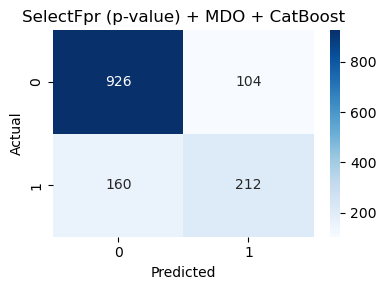

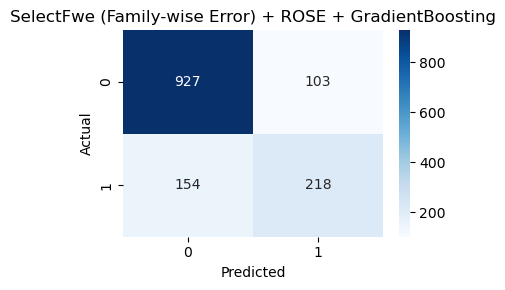

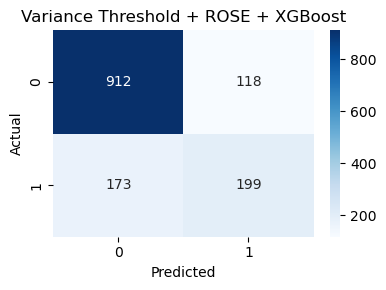

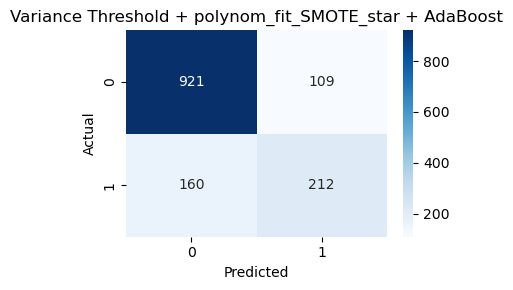

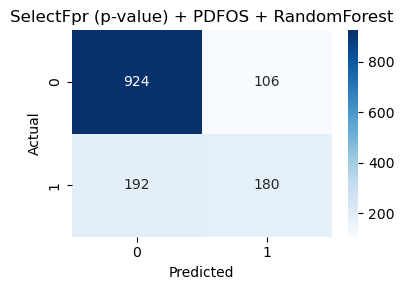

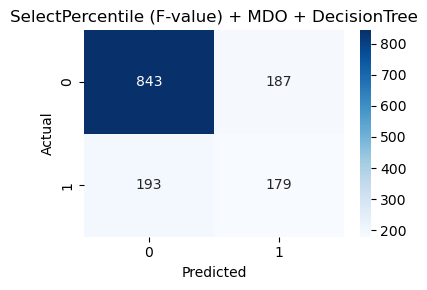

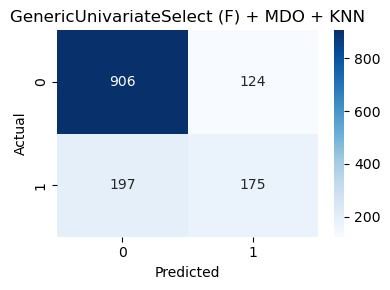

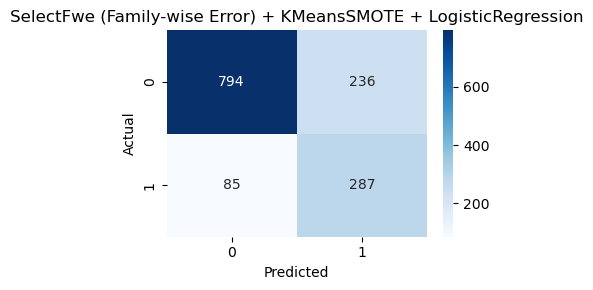

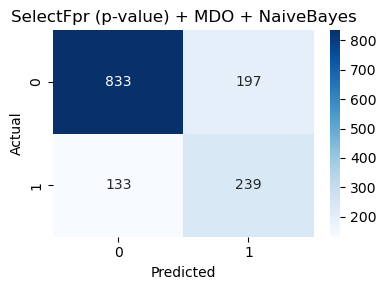

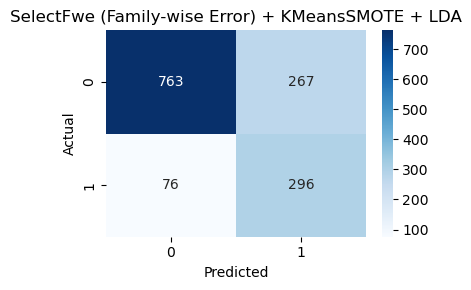

In [38]:
# Store best confusion matrix data per classifier
best_cm_data = {}

# Loop through each classifier and get the best (highest accuracy) combination
for clf in tuned_results_df['Classifier'].unique():
    # Get the row with the best accuracy for this classifier
    best_row = tuned_results_df[tuned_results_df['Classifier'] == clf].sort_values(by="Accuracy", ascending=False).iloc[0]

    fs = best_row["Selector"]
    smote = best_row["Oversampler"]

    # Find the matching confusion data
    match = next((entry for entry in confusion_data if
                  entry["Classifier"] == clf and
                  entry["Selector"] == fs and
                  entry["Oversampler"] == smote), None)

    if match:
        best_cm_data[clf] = match

# Plot only 10 confusion matrices (1 per classifier)
for clf, data in best_cm_data.items():
    cm = confusion_matrix(data["y_true"], data["y_pred"])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{data['Selector']} + {data['Oversampler']} + {clf}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

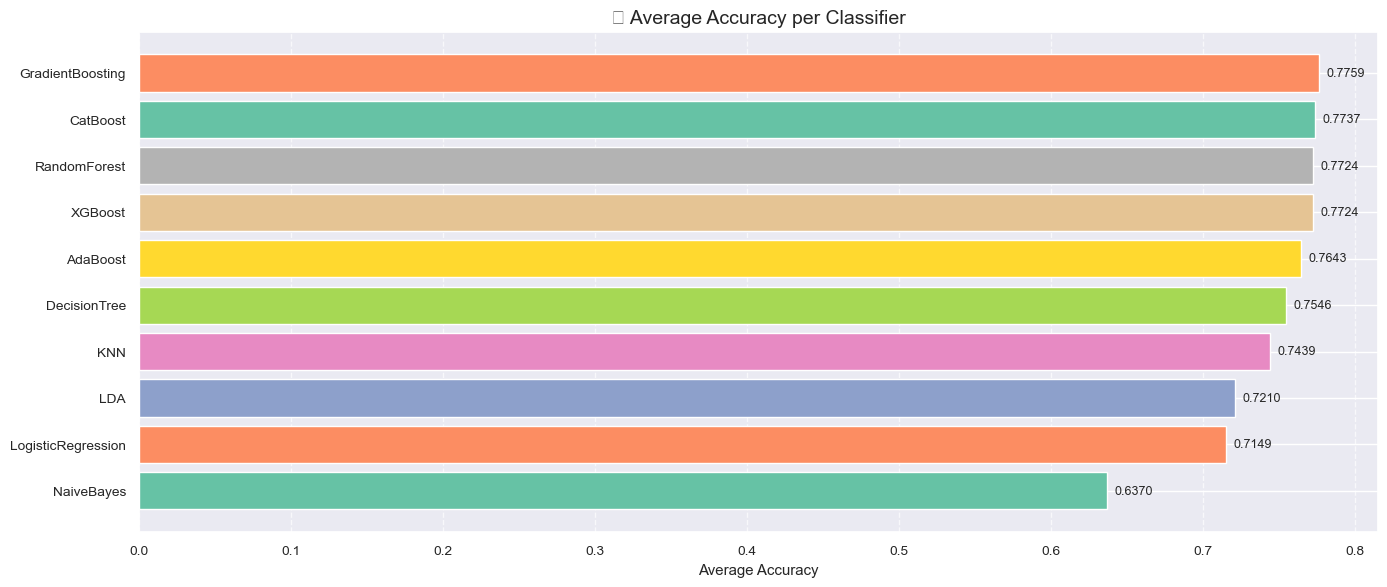

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute average accuracy per classifier
avg_acc = tuned_results_df.groupby("Classifier")[["Accuracy"]].mean().reset_index()
avg_acc = avg_acc.sort_values(by="Accuracy", ascending=True)

# Plot
plt.figure(figsize=(14, 6))
colors = sns.color_palette("Set2", len(avg_acc))

bars = plt.barh(avg_acc["Classifier"], avg_acc["Accuracy"], color=colors)

# Add grid and title
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.title("📊 Average Accuracy per Classifier", fontsize=14)
plt.xlabel("Average Accuracy")

# Annotate each bar with the Accuracy value
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f"{width:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

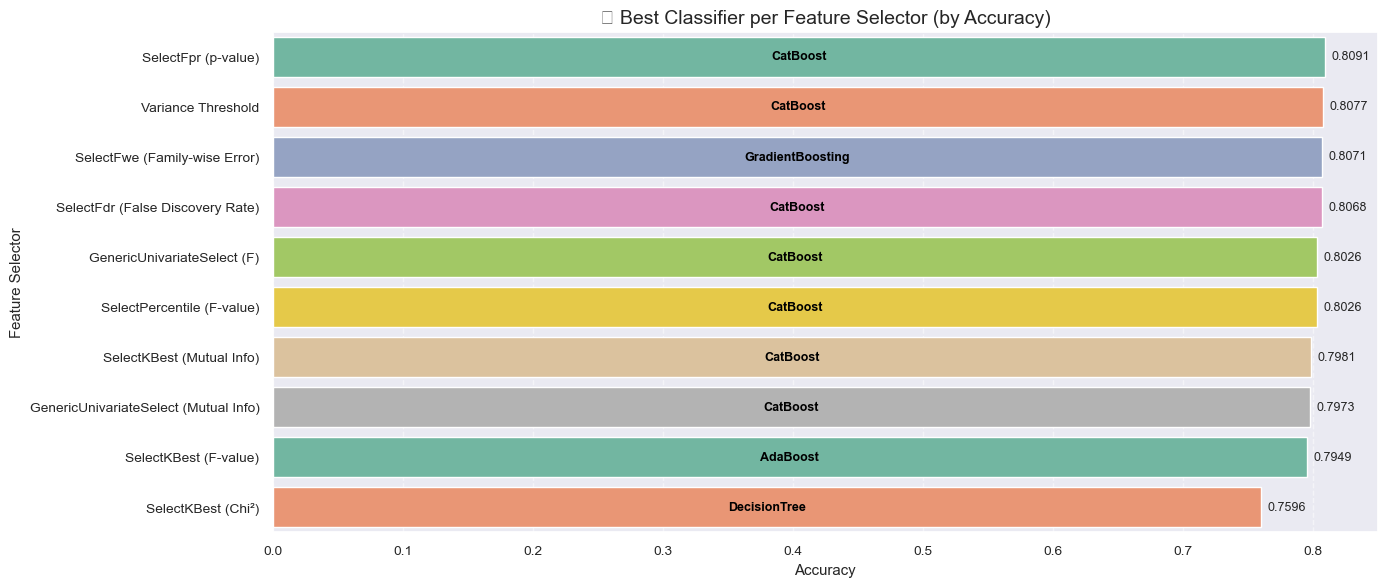

In [50]:
# Get best classifier per feature selector
best_by_fs = tuned_results_df.sort_values(by='Accuracy', ascending=False).groupby("Selector").first().reset_index()

# Sort for better visual alignment
best_by_fs = best_by_fs.sort_values(by="Accuracy", ascending=False)

# Plot setup
plt.figure(figsize=(14, 6))
colors = sns.color_palette("Set2", len(best_by_fs))
bars = sns.barplot(data=best_by_fs, y="Selector", x="Accuracy", palette=colors)

# Annotate classifier names *inside* the bars
for bar, classifier in zip(bars.patches, best_by_fs['Classifier']):
    width = bar.get_width()
    plt.text(width * 0.5, bar.get_y() + bar.get_height()/2,
             classifier, ha='center', va='center', fontsize=9, color='black', fontweight='bold')

# Annotate accuracy values *at the end* of bars
for bar in bars.patches:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f"{width:.4f}", ha='left', va='center', fontsize=9)

# Final plot formatting
plt.title("🎯 Best Classifier per Feature Selector (by Accuracy)", fontsize=14)
plt.xlabel("Accuracy")
plt.ylabel("Feature Selector")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


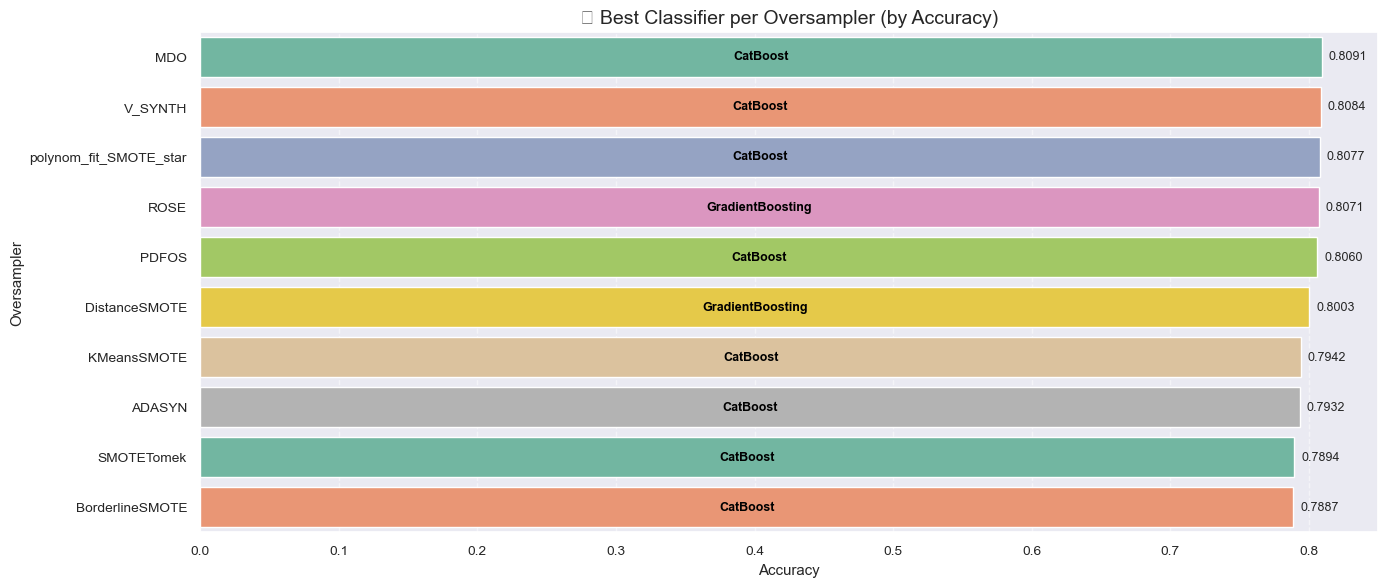

In [52]:
# Get best classifier per oversampler
best_by_os = tuned_results_df.sort_values(by='Accuracy', ascending=False).groupby("Oversampler").first().reset_index()

# Sort for better visuals
best_by_os = best_by_os.sort_values(by="Accuracy", ascending=False)

# Plot
plt.figure(figsize=(14, 6))
colors = sns.color_palette("Set2", len(best_by_os))
bars = sns.barplot(data=best_by_os, y="Oversampler", x="Accuracy", palette=colors)

# Annotate classifier names inside bars
for bar, classifier in zip(bars.patches, best_by_os['Classifier']):
    width = bar.get_width()
    plt.text(width * 0.5, bar.get_y() + bar.get_height() / 2,
             classifier, ha='center', va='center', fontsize=9, color='black', fontweight='bold')

# Annotate accuracy values at end of bars
for bar in bars.patches:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height() / 2,
             f"{width:.4f}", ha='left', va='center', fontsize=9)

# Final plot settings
plt.title("📈 Best Classifier per Oversampler (by Accuracy)", fontsize=14)
plt.xlabel("Accuracy")
plt.ylabel("Oversampler")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

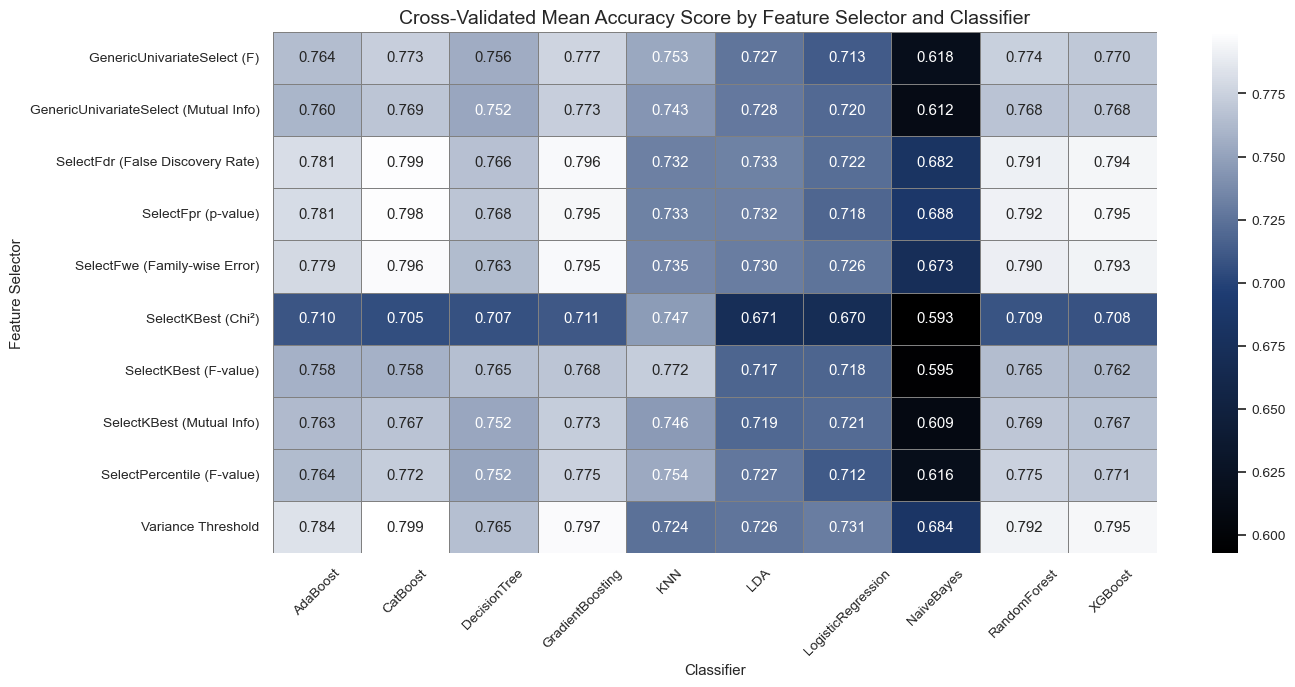

In [42]:
from matplotlib.colors import LinearSegmentedColormap

black_blue_white = LinearSegmentedColormap.from_list(
    "BlackBlueWhite", ["#000000", "#1e3c72", "#ffffff"], N=256
)


# 🔹 Pivot table: Max Accuracy Score for each Feature Selector–Classifier pair
pivot_fs_clf = tuned_results_df.pivot_table(
    index='Selector',
    columns='Classifier',
    values='Accuracy', 
    aggfunc='mean'
)

# 🔹 Plot heatmap
plt.figure(figsize=(14, 7))
sns.set(font_scale=0.9)
sns.heatmap(
    pivot_fs_clf,
    annot=True,
    fmt=".3f",
    cmap=black_blue_white,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Cross-Validated Mean Accuracy Score by Feature Selector and Classifier", fontsize=14)
plt.xlabel("Classifier")
plt.ylabel("Feature Selector")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


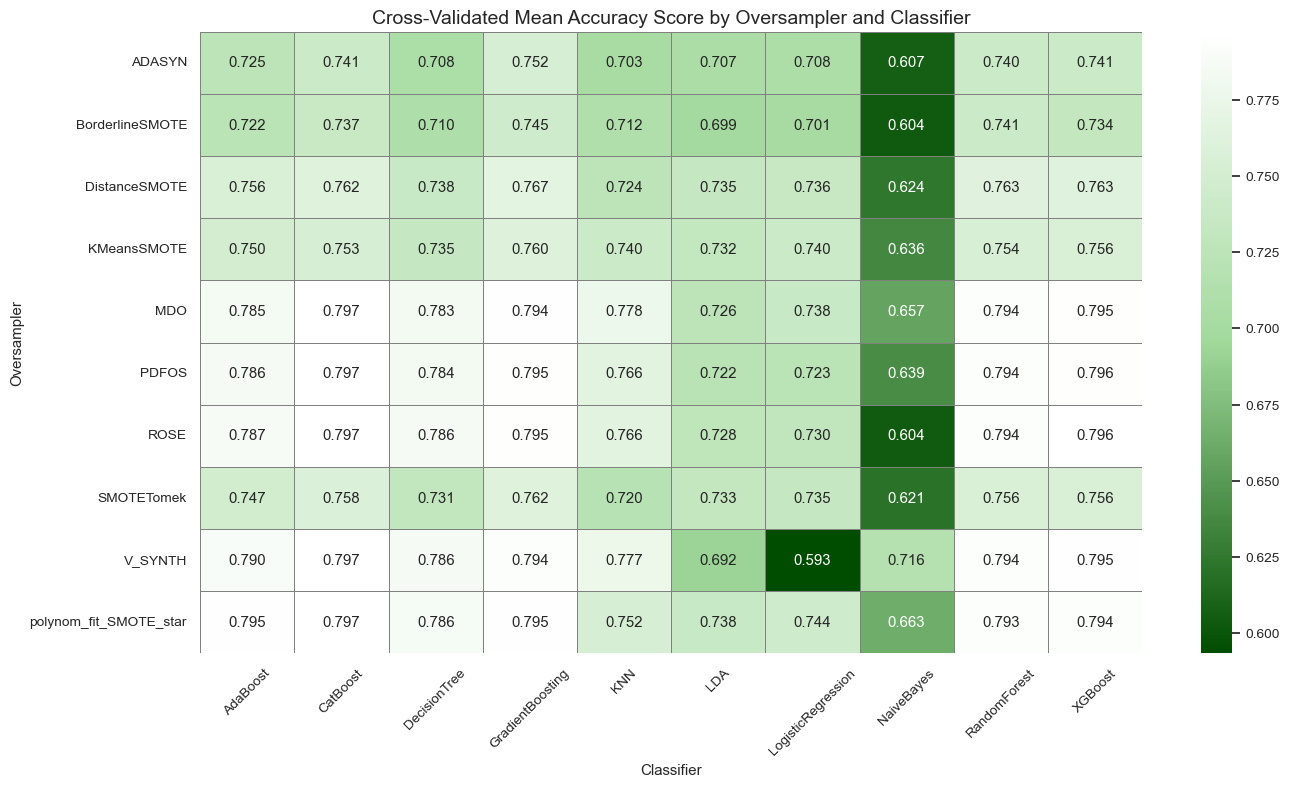

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# 🌈 Custom colormap: Deep green → Light green → White
green_white = LinearSegmentedColormap.from_list(
    "GreenWhite", ["#004d00", "#a1d99b", "#ffffff"], N=256
)

# 🔹 Pivot table: Max Accuracy for Oversampler–Classifier combination
pivot_os_clf = tuned_results_df.pivot_table(
    index="Oversampler",
    columns="Classifier",
    values="Accuracy",
    aggfunc="mean"  
)

# 🖼️ Plot the heatmap
plt.figure(figsize=(14, 8))
sns.set(font_scale=0.9)
sns.heatmap(
    pivot_os_clf,
    annot=True,
    fmt=".3f",
    cmap=green_white,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Cross-Validated Mean Accuracy Score by Oversampler and Classifier", fontsize=14)
plt.xlabel("Classifier")
plt.ylabel("Oversampler")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


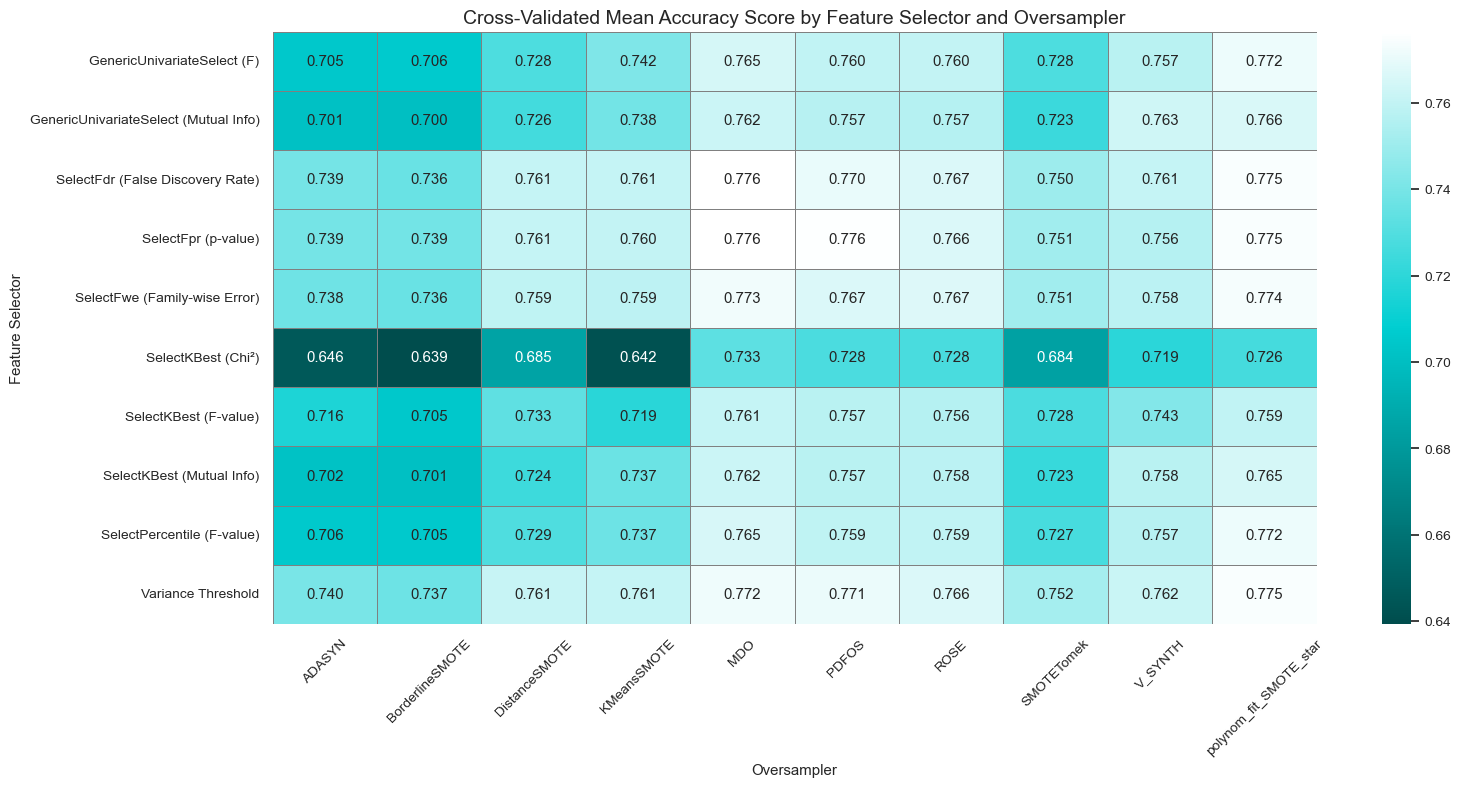

In [44]:
teal_cyan_white = LinearSegmentedColormap.from_list(
    "TealCyanWhite", ["#004d4d", "#00ced1", "#ffffff"], N=256
)


pivot_Acc = tuned_results_df.pivot_table(
    index="Selector", 
    columns="Oversampler", 
    values="Accuracy", 
    aggfunc="mean"  
)

# 🔹 Plot heatmap
plt.figure(figsize=(16, 8))
sns.set(font_scale=0.9)
sns.heatmap(
    pivot_Acc,
    annot=True,
    fmt=".3f",
    cmap=teal_cyan_white,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Cross-Validated Mean Accuracy Score by Feature Selector and Oversampler", fontsize=14)
plt.xlabel("Oversampler")
plt.ylabel("Feature Selector")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

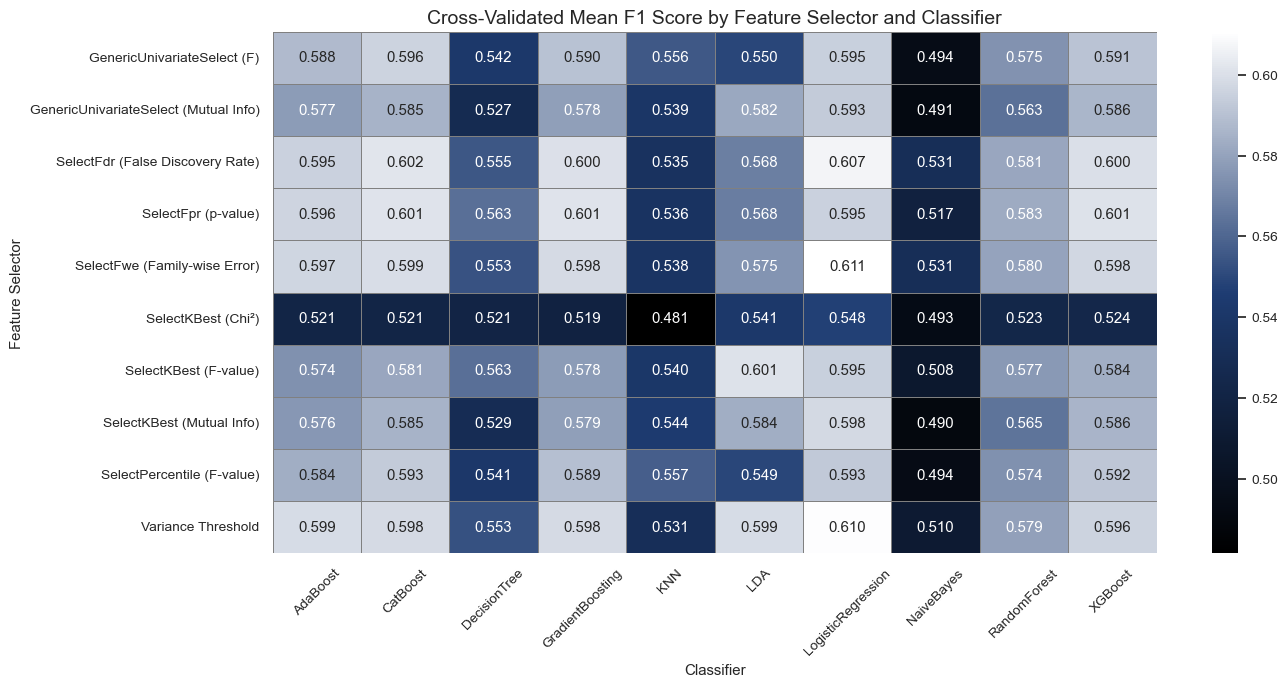

In [45]:
from matplotlib.colors import LinearSegmentedColormap

black_blue_white = LinearSegmentedColormap.from_list(
    "BlackBlueWhite", ["#000000", "#1e3c72", "#ffffff"], N=256
)

# 🔹 Pivot table: Max F1 Score for each Feature Selector–Classifier pair
pivot_fs_clf = tuned_results_df.pivot_table(
    index='Selector',
    columns='Classifier',
    values='F1',  
    aggfunc='mean'
)

# 🔹 Plot heatmap
plt.figure(figsize=(14, 7))
sns.set(font_scale=0.9)
sns.heatmap(
    pivot_fs_clf,
    annot=True,
    fmt=".3f",
    cmap=black_blue_white,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Cross-Validated Mean F1 Score by Feature Selector and Classifier", fontsize=14)
plt.xlabel("Classifier")
plt.ylabel("Feature Selector")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

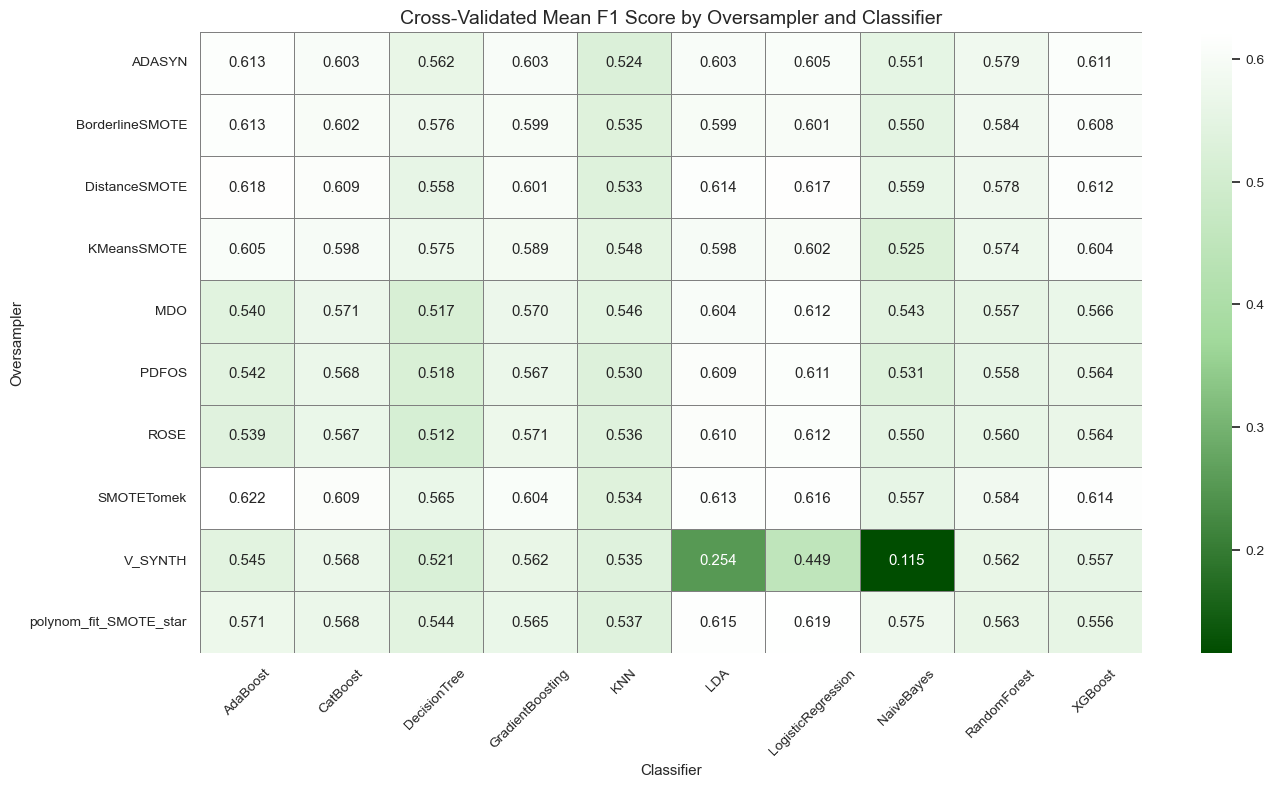

In [46]:
green_white = LinearSegmentedColormap.from_list(
    "GreenWhite", ["#004d00", "#a1d99b", "#ffffff"], N=256
)

# 🔹 Pivot table: Max F1 Score for Oversampler–Classifier combination
pivot_os_clf = tuned_results_df.pivot_table(
    index="Oversampler",
    columns="Classifier",
    values="F1",
    aggfunc="mean" 
)

# 🖼️ Plot the heatmap
plt.figure(figsize=(14, 8))
sns.set(font_scale=0.9)
sns.heatmap(
    pivot_os_clf,
    annot=True,
    fmt=".3f",
    cmap=green_white,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Cross-Validated Mean F1 Score by Oversampler and Classifier", fontsize=14)
plt.xlabel("Classifier")
plt.ylabel("Oversampler")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

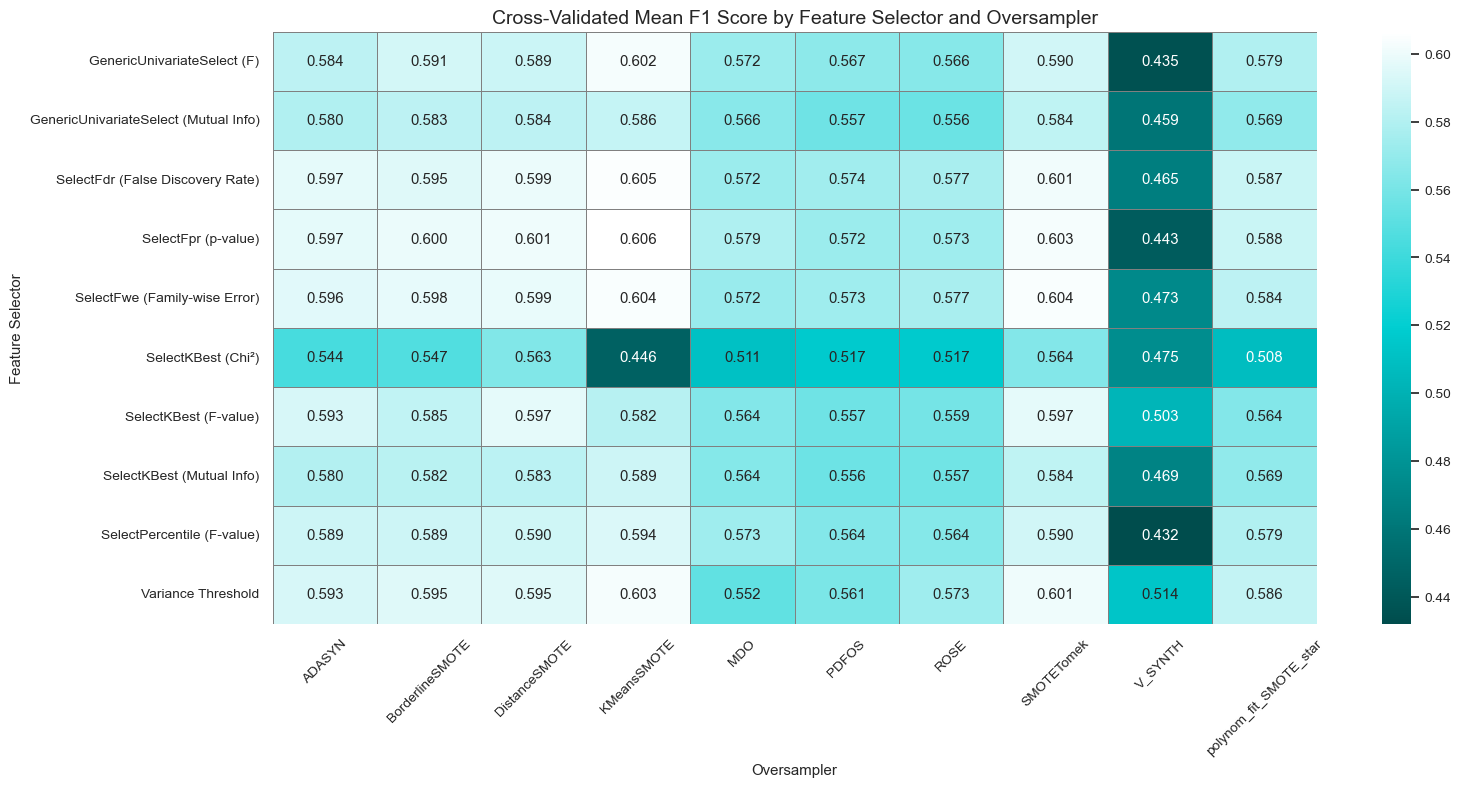

In [47]:
teal_cyan_white = LinearSegmentedColormap.from_list(
    "TealCyanWhite", ["#004d4d", "#00ced1", "#ffffff"], N=256
)

pivot_Acc = tuned_results_df.pivot_table(
    index="Selector", 
    columns="Oversampler", 
    values="F1", 
    aggfunc="mean"  
)

# 🔹 Plot heatmap
plt.figure(figsize=(16, 8))
sns.set(font_scale=0.9)
sns.heatmap(
    pivot_Acc,
    annot=True,
    fmt=".3f",
    cmap=teal_cyan_white
,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Cross-Validated Mean F1 Score by Feature Selector and Oversampler", fontsize=14)
plt.xlabel("Oversampler")
plt.ylabel("Feature Selector")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()